
# Build a Mini-Transformer (nanoGPT)


In [ ]:


import math
import time
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.nn import functional as F

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch version: 2.11.0+cu128
CUDA available: True
Using device: cuda
GPU: Tesla T4



## 3. Get a small text corpus

We use **Tiny Shakespeare**, a commonly used small corpus for character-level language-model demonstrations.

The model does not memorize a pre-built answer. It learns statistical patterns from the training text and then predicts one character at a time.


In [ ]:


data_url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
data_path = Path("input.txt")

if not data_path.exists():
    urllib.request.urlretrieve(data_url, data_path)

text = data_path.read_text(encoding="utf-8")

print("Characters in corpus:", len(text))
print("\nFirst 500 characters:\n")
print(text[:500])


Characters in corpus: 1115394

First 500 characters:

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor



## 4. Character-level tokenizer and next-token prediction

Here, every unique character becomes a token.

For example:

`"hello"` → `[token(h), token(e), token(l), token(l), token(o)]`

The training task is:

> **Given the previous characters, predict the next character.**

If the input is:

`To be`

the model learns to predict what character is likely to come next.

This is the basic training idea behind GPT-style autoregressive language models, although real LLMs normally use subword tokens rather than individual characters.


In [ ]:

# Build vocabulary

chars = sorted(list(set(text)))
vocab_size = len(chars)

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

encode = lambda s: [stoi[c] for c in s]
decode = lambda ids: "".join(itos[i] for i in ids)

data = torch.tensor(encode(text), dtype=torch.long)

# Train/validation split
n = int(0.90 * len(data))
train_data = data[:n]
val_data = data[n:]

print("Vocabulary size:", vocab_size)
print("Training characters:", len(train_data))
print("Validation characters:", len(val_data))

print("\nExample:")
example = "To be"
ids = encode(example)
print("Text:", example)
print("Token IDs:", ids)
print("Decoded back:", decode(ids))


Vocabulary size: 65
Training characters: 1003854
Validation characters: 111540

Example:
Text: To be
Token IDs: [32, 53, 1, 40, 43]
Decoded back: To be


In [ ]:

# Hyperparameters

batch_size = 64
block_size = 128
max_iters = 3000
eval_interval = 300
eval_iters = 100

learning_rate = 3e-4
n_embd = 128
n_head = 4
n_layer = 4
dropout = 0.1

torch.manual_seed(1337)

print("Model configuration:")
print("Embedding size:", n_embd)
print("Attention heads:", n_head)
print("Transformer layers:", n_layer)
print("Context length:", block_size)
print("Training iterations:", max_iters)


Model configuration:
Embedding size: 128
Attention heads: 4
Transformer layers: 4
Context length: 128
Training iterations: 3000



## 5. Create training batches

A batch contains many short pieces of text.

For each input sequence `x`, the target `y` is the same sequence shifted one character to the left.

Example:

```text
x: T o   b e
y: o   b e ...
```

So the model is repeatedly asked:

**"What comes next?"**


In [ ]:

def get_batch(split):
    source = train_data if split == "train" else val_data

    ix = torch.randint(len(source) - block_size, (batch_size,))
    x = torch.stack([source[i:i + block_size] for i in ix])
    y = torch.stack([source[i + 1:i + block_size + 1] for i in ix])

    return x.to(device), y.to(device)

xb, yb = get_batch("train")

print("Input batch shape :", xb.shape)
print("Target batch shape:", yb.shape)

print("\nOne example input:")
print(decode(xb[0].tolist())[:150])

print("\nCorresponding target:")
print(decode(yb[0].tolist())[:150])


Input batch shape : torch.Size([64, 128])
Target batch shape: torch.Size([64, 128])

One example input:
 guess who caused your father's death.

Boy:
Grandam, we can; for my good uncle Gloucester
Told me, the king, provoked by the qu

Corresponding target:
guess who caused your father's death.

Boy:
Grandam, we can; for my good uncle Gloucester
Told me, the king, provoked by the que



# 6. Transformer building blocks

Our mini-GPT is made from these main pieces:

1. **Token embedding** — converts token IDs into vectors.
2. **Positional embedding** — tells the model where each token occurs.
3. **Causal self-attention** — lets a token look at earlier tokens, but not future tokens.
4. **MLP / feed-forward network** — transforms each position's representation.
5. **LayerNorm** — stabilizes the network.
6. **Residual connections** — help information and gradients flow through layers.
7. **Linear output head** — converts the final representation into scores for every possible next token.

The architecture is **decoder-only**, like the core architecture used by GPT-style models.


In [ ]:

class Head(nn.Module):
    """One causal self-attention head."""
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)

        # Lower-triangular mask prevents looking into the future.
        self.register_buffer("tril", torch.tril(torch.ones(block_size, block_size)))

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape

        k = self.key(x)       # (B, T, head_size)
        q = self.query(x)     # (B, T, head_size)

        # Attention scores
        weights = q @ k.transpose(-2, -1)
        weights = weights * (k.shape[-1] ** -0.5)

        # Causal masking
        weights = weights.masked_fill(self.tril[:T, :T] == 0, float("-inf"))
        weights = F.softmax(weights, dim=-1)
        weights = self.dropout(weights)

        v = self.value(x)
        out = weights @ v

        return out


class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList(
            [Head(head_size) for _ in range(num_heads)]
        )
        self.proj = nn.Linear(num_heads * head_size, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.proj(out)
        return self.dropout(out)


class FeedForward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head

        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)

        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        # Residual connection around attention
        x = x + self.sa(self.ln1(x))

        # Residual connection around feed-forward network
        x = x + self.ffwd(self.ln2(x))

        return x


In [ ]:

class MiniGPT(nn.Module):
    def __init__(self):
        super().__init__()

        # 1. Token embedding
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)

        # 2. Positional embedding
        self.position_embedding_table = nn.Embedding(block_size, n_embd)

        # 3. Transformer blocks
        self.blocks = nn.Sequential(
            *[Block(n_embd, n_head) for _ in range(n_layer)]
        )

        # 4. Final normalization
        self.ln_f = nn.LayerNorm(n_embd)

        # 5. Output head: vector -> scores for each vocabulary token
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # Token + position information
        token_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(
            torch.arange(T, device=device)
        )

        x = token_emb + pos_emb

        # Transformer
        x = self.blocks(x)
        x = self.ln_f(x)

        # Next-token logits
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            B, T, C = logits.shape
            logits_flat = logits.view(B * T, C)
            targets_flat = targets.view(B * T)
            loss = F.cross_entropy(logits_flat, targets_flat)

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            # Keep only the most recent context
            idx_cond = idx[:, -block_size:]

            logits, _ = self(idx_cond)

            # Focus on the final time step
            logits = logits[:, -1, :]

            # Convert scores into probabilities
            probs = F.softmax(logits, dim=-1)

            # Sample the next token
            idx_next = torch.multinomial(probs, num_samples=1)

            idx = torch.cat((idx, idx_next), dim=1)

        return idx


model = MiniGPT().to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters: {num_params:,}")


Number of parameters: 824,897



## 7. Architecture walkthrough

The flow is:

**Characters → Token IDs → Token Embeddings + Position Embeddings → Transformer Blocks → LayerNorm → Output Scores → Next Character**

Each Transformer block contains:

**LayerNorm → Causal Multi-Head Self-Attention → Residual Add → LayerNorm → MLP → Residual Add**

### Why causal attention?

When predicting the next character, the model must not cheat by seeing characters that come later in the sequence.

The triangular mask makes the attention matrix look conceptually like this:

```text
        Seen by each position
        1  2  3  4  5
1       ✓  ✗  ✗  ✗  ✗
2       ✓  ✓  ✗  ✗  ✗
3       ✓  ✓  ✓  ✗  ✗
4       ✓  ✓  ✓  ✓  ✗
5       ✓  ✓  ✓  ✓  ✓
```

So position 4 can use positions 1–4, but cannot use position 5.


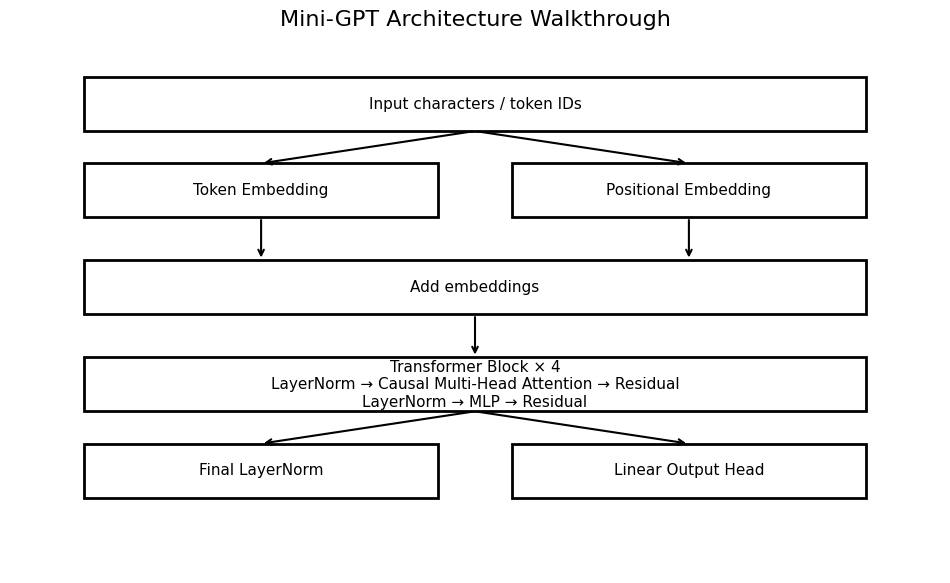

In [ ]:

# Visual architecture diagram

fig, ax = plt.subplots(figsize=(12, 7))
ax.axis("off")

boxes = [
    (0.08, 0.82, 0.84, 0.10, "Input characters / token IDs"),
    (0.08, 0.66, 0.38, 0.10, "Token Embedding"),
    (0.54, 0.66, 0.38, 0.10, "Positional Embedding"),
    (0.08, 0.48, 0.84, 0.10, "Add embeddings"),
    (0.08, 0.30, 0.84, 0.10, "Transformer Block × 4\nLayerNorm → Causal Multi-Head Attention → Residual\nLayerNorm → MLP → Residual"),
    (0.08, 0.14, 0.38, 0.10, "Final LayerNorm"),
    (0.54, 0.14, 0.38, 0.10, "Linear Output Head"),
]

for x, y, w, h, label in boxes:
    ax.add_patch(plt.Rectangle((x, y), w, h, fill=False, linewidth=2))
    ax.text(x + w/2, y + h/2, label, ha="center", va="center", fontsize=11)

arrows = [
    ((0.50, 0.82), (0.27, 0.76)),
    ((0.50, 0.82), (0.73, 0.76)),
    ((0.27, 0.66), (0.27, 0.58)),
    ((0.73, 0.66), (0.73, 0.58)),
    ((0.50, 0.48), (0.50, 0.40)),
    ((0.50, 0.30), (0.27, 0.24)),
    ((0.50, 0.30), (0.73, 0.24)),
]

for start, end in arrows:
    ax.annotate("", xy=end, xytext=start,
                arrowprops=dict(arrowstyle="->", linewidth=1.5))

ax.set_title("Mini-GPT Architecture Walkthrough", fontsize=16)
plt.show()



## 8. Train the model

The optimizer changes the model's parameters so that its predicted next character becomes closer to the actual next character.

We use **cross-entropy loss**.

A lower loss generally means the model is getting better at predicting the training sequence. We also track validation loss to check how well it generalizes to text it did not train on.


In [ ]:

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()

    for split in ["train", "val"]:
        losses = torch.zeros(eval_iters)

        for k in range(eval_iters):
            X, Y = get_batch(split)
            _, loss = model(X, Y)
            losses[k] = loss.item()

        out[split] = losses.mean().item()

    model.train()
    return out


optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

train_losses = []
val_losses = []
steps_recorded = []

start_time = time.time()

for step in range(max_iters):
    if step % eval_interval == 0 or step == max_iters - 1:
        losses = estimate_loss()
        train_losses.append(losses["train"])
        val_losses.append(losses["val"])
        steps_recorded.append(step)

        print(
            f"step {step:4d} | "
            f"train loss {losses['train']:.4f} | "
            f"val loss {losses['val']:.4f}"
        )

    xb, yb = get_batch("train")

    logits, loss = model(xb, yb)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

elapsed = time.time() - start_time
print(f"\nTraining time: {elapsed/60:.2f} minutes")


step    0 | train loss 4.3265 | val loss 4.3262
step  300 | train loss 2.4545 | val loss 2.4647
step  600 | train loss 2.2541 | val loss 2.2762
step  900 | train loss 2.0546 | val loss 2.1029
step 1200 | train loss 1.9181 | val loss 2.0015
step 1500 | train loss 1.8175 | val loss 1.9292
step 1800 | train loss 1.7362 | val loss 1.8706
step 2100 | train loss 1.6751 | val loss 1.8297
step 2400 | train loss 1.6335 | val loss 1.8023
step 2700 | train loss 1.5949 | val loss 1.7603
step 2999 | train loss 1.5640 | val loss 1.7417

Training time: 2.22 minutes



## 9. Loss curve and generated text

Two important pieces of evidence for the project are:

- **Loss curve:** shows whether training is learning.
- **Generated samples:** show what the trained model can produce.

The generated text will not necessarily be grammatically perfect. This is a deliberately small model trained on a small corpus.


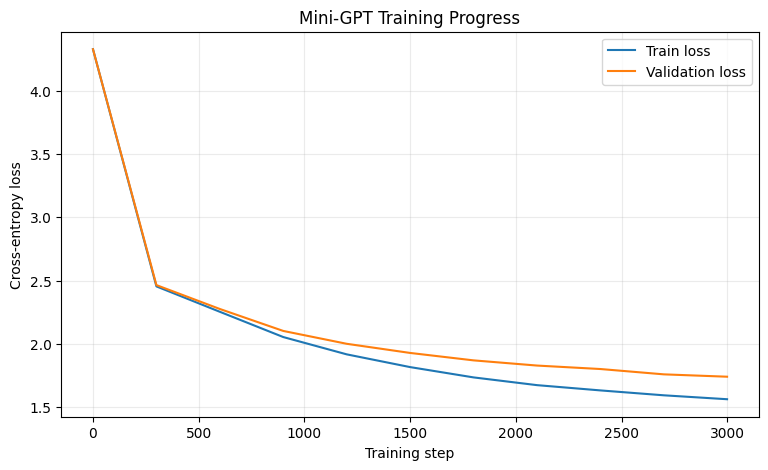

In [ ]:

# Plot loss

plt.figure(figsize=(9, 5))
plt.plot(steps_recorded, train_losses, label="Train loss")
plt.plot(steps_recorded, val_losses, label="Validation loss")
plt.xlabel("Training step")
plt.ylabel("Cross-entropy loss")
plt.title("Mini-GPT Training Progress")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()


In [ ]:

# Generate text

model.eval()

context_text = "ROMEO:"
context = torch.tensor(
    [encode(context_text)],
    dtype=torch.long,
    device=device
)

generated = model.generate(context, max_new_tokens=600)[0].tolist()

print(decode(generated))


ROMEO:
No, and I cause is neced him ablactions light:
They settemply fain not use 'thing fled.
Pray'd life, and Come for candsron of couldren grory?

MENENIUS:
Not is suchest him I say, the done.'

ANTIGO:
You good ways p thing yie with ten your commonations;
And house bo not yet, where have sir. Not doth good's drey,
No, what I may did trawful was dead in me:
All mooth I hast to his the up!
The of Guill where shall a Greforth craces: belaus,
Shall no shall senforld speak will and of right:
Who'er lody devil to and my lords;
We shall she your, belook the see true poor
The mose prose to soul?

ANGELO



## 10. Demonstrate next-token prediction

The model produces a probability distribution over the entire vocabulary for the next character.

We can inspect the most likely next characters for a prompt.


In [ ]:

# Show top predicted next characters for a prompt

model.eval()

prompt = "ROMEO:"
context = torch.tensor([encode(prompt)], dtype=torch.long, device=device)

with torch.no_grad():
    logits, _ = model(context)
    next_logits = logits[:, -1, :]
    probs = F.softmax(next_logits, dim=-1)[0]

top_probs, top_ids = torch.topk(probs, k=min(10, vocab_size))

print("Prompt:", repr(prompt))
print("\nTop next-character predictions:")

for prob, idx in zip(top_probs.tolist(), top_ids.tolist()):
    ch = itos[idx]
    printable = repr(ch)
    print(f"{printable:>6}  probability={prob:.4f}")


Prompt: 'ROMEO:'

Top next-character predictions:
  '\n'  probability=0.9936
   ' '  probability=0.0053
   "'"  probability=0.0004
   '-'  probability=0.0002
   '.'  probability=0.0001
   '?'  probability=0.0001
   ','  probability=0.0000
   '!'  probability=0.0000
   ';'  probability=0.0000
   '3'  probability=0.0000
